<a href="https://colab.research.google.com/github/vaggelis-ahmeti/MEM-256-1st-PROJECT/blob/main/1st_project_(3250).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**GOLDEN SECTION**

In [14]:
import math

def golden(f, a0, b0, tol, NMAX=50):
    rho = (3 - math.sqrt(5)) / 2  # 0.382
    a = a0
    b = b0
    a1 = a + rho*(b - a)
    b1 = a + (1-rho)*(b - a)
    f1 = f(a1)
    f2 = f(b1)

    print("k | a | b | a1 | f(a1) | b1 | f(b1) | Adjusted interval")

    for k in range(1, NMAX+1):
        print(f"{k} | {a:.6f} | {b:.6f} | {a1:.6f} | {f1:.6f} | {b1:.6f} | {f2:.6f} | [{a:.6f},{b:.6f}]")

        if f1 < f2:
            b = b1
            b1 = a1
            f2 = f1
            a1 = a + rho*(b - a)
            f1 = f(a1)
        else:
            a = a1
            a1 = b1
            f1 = f2
            b1 = b - rho*(b - a)
            f2 = f(b1)

        if abs(b - a) < tol:
            break

    x_star = (a + b)/2
    return a, b, x_star, k




#EXERCISE. 1:


def f(x):
    return x**2 + 4*math.cos(x)

a0 = 1
b0 = 2
tol = 0.05
NMAX = 50

a, b, x_star, iters = golden(f, a0, b0, tol, NMAX)
print(f"\nΤελικό διάστημα: [{a:.6f}, {b:.6f}]")
print(f" x_star = {x_star:.6f}")
print(f"Iterations: {iters}")



#EXERCISE. 2:


def f(x):
    return 2*np.exp(-x) + np.log(x)

a0 = 2
b0 = 3
tol = 0.1
NMAX = 50

a, b, x_star, iters = golden(f, a0, b0, tol, NMAX)
print(f"\nΤελικό διάστημα: [{a:.6f}, {b:.6f}]")
print(f" x_star = {x_star:.6f}")
print(f"Iterations: {iters}")


k | a | b | a1 | f(a1) | b1 | f(b1) | Adjusted interval
1 | 1.000000 | 2.000000 | 1.381966 | 2.660671 | 1.618034 | 2.429154 | [1.000000,2.000000]
2 | 1.381966 | 2.000000 | 1.618034 | 2.429154 | 1.763932 | 2.343707 | [1.381966,2.000000]
3 | 1.618034 | 2.000000 | 1.763932 | 2.343707 | 1.854102 | 2.319570 | [1.618034,2.000000]
4 | 1.763932 | 2.000000 | 1.854102 | 2.319570 | 1.909830 | 2.317147 | [1.763932,2.000000]
5 | 1.854102 | 2.000000 | 1.909830 | 2.317147 | 1.944272 | 2.320779 | [1.854102,2.000000]
6 | 1.854102 | 1.944272 | 1.888544 | 2.316887 | 1.909830 | 2.317147 | [1.854102,1.944272]
7 | 1.854102 | 1.909830 | 1.875388 | 2.317465 | 1.888544 | 2.316887 | [1.854102,1.909830]

Τελικό διάστημα: [1.875388, 1.909830]
 x_star = 1.892609
Iterations: 7
k | a | b | a1 | f(a1) | b1 | f(b1) | Adjusted interval
1 | 2.000000 | 3.000000 | 2.381966 | 1.052664 | 2.618034 | 1.108316 | [2.000000,3.000000]
2 | 2.000000 | 2.618034 | 2.236068 | 1.018475 | 2.381966 | 1.052664 | [2.000000,2.618034]
3 | 2.

**NEWTON'S METHOD**

In [15]:
import numpy as np

def newton(x_old, f, d_f, d2_f, tol, NMAX):

    iter = 1

    print("Newton's Method")
    print("k | x_k | f(x_k) | f'(x_k) | f''(x_k) | x_{k+1} | Error")

    while iter <= NMAX:

        x_new = x_old - d_f(x_old)/d2_f(x_old)

        err = abs(x_new - x_old)

        print(iter, "|", x_old, "|", f(x_old), "|", d_f(x_old), "|", d2_f(x_old), "|", x_new, "|", err)

        if err < tol:
            break

        x_old = x_new
        iter += 1

    return x_new, err, iter

#EXERCISE. 1

def f(x):
    return x**2 + 4*np.cos(x)

def d_f(x):
    return 2*x - 4*np.sin(x)

def d2_f(x):
    return 2 - 4*np.cos(x)

x0 = 1
tol = 0.05
NMAX = 50

x_star, err, it = newton(x0, f, d_f, d2_f, tol, NMAX)


print("\nFinal Result:")
print("x_star =", x_star)
print("iterations =", it)
print("error =", err)



#EXERCISE. 2

def f(x):
    return 2*np.exp(-x) + np.log(x)

def d_f(x):
    return -2*np.exp(-x) + 1/x

def d2_f(x):
    return 2*np.exp(-x) - 1/(x**2)

x0 = 1
tol = 0.1
NMAX = 50

x_star, err, it = newton(x0, f, d_f, d2_f, tol, NMAX)


print("\nFinal Result:")
print("x_star =", x_star)
print("iterations =", it)
print("error =", err)



Newton's Method
k | x_k | f(x_k) | f'(x_k) | f''(x_k) | x_{k+1} | Error
1 | 1 | 3.161209223472559 | -1.365883939231586 | -0.16120922347255906 | -7.4727406398312315 | 8.472740639831231
2 | -7.4727406398312315 | 57.33014327366494 | -11.232666837814586 | 0.5117093965203434 | 14.478520982873837 | 21.95126162270507
3 | 14.478520982873837 | 208.28851659077012 | 25.187832981772328 | 3.339053260747886 | 6.935115408046103 | 7.543405574827734
4 | 6.935115408046103 | 51.275482705508004 | 11.443343617833992 | -1.1796569825895364 | 16.63568412143092 | 9.700568713384817
5 | 16.63568412143092 | 274.34734843892346 | 36.47238947811892 | 4.398637749105362 | 8.34393754931617 | 8.29174657211475
6 | 8.34393754931617 | 67.7389458654033 | 13.158460678095539 | 3.8823479614850385 | 4.954632724340541 | 3.3893048249756292
7 | 4.954632724340541 | 25.507911272967622 | 13.79247419437557 | 1.0404741601385432 | -8.301317997721647 | 13.255950722062188
8 | -8.301317997721647 | 67.18161837781092 | -12.996226008912458 | 

/tmp/ipykernel_202/2574659023.py:54: RuntimeWarning: invalid value encountered in log
  return 2*np.exp(-x) + np.log(x)


**SECANT METHOD**

In [16]:
import numpy as np

def secant_method(f, df, x0, x1, tol, NMAX):

    slope = (df(x1) - df(x0)) / (x1 - x0)
    x_new = x1 - df(x1)/slope

    err = abs(x_new - x1)
    k = 1

    print("Secant Method")
    print("k | x_k | f(x_k) | f'(x_k) | x_{k+1} | Error")

    while (k <= NMAX) and (err > tol):

        print(f"{k} | {x1:.6f} | {f(x1):.6f} | {df(x1):.6f} | {x_new:.6f} | {err:.6f}")

        x0 = x1
        x1 = x_new

        slope = (df(x1) - df(x0)) / (x1 - x0)
        x_new = x1 - df(x1)/slope

        err = abs(x_new - x1)
        k += 1

    return x_new, k


#EXERCISE. 1:


def f(x):
    return x**2 + 4*np.cos(x)


def df(x):
    return 2*x - 4*np.sin(x)


x0 = 1
x1 = 1.5
tol = 0.05
NMAX = 50

x_star, it = secant_method(f, df, x0, x1, tol, NMAX)

print("x_star= ", x_star)
print("Iterations:", it)



#EXERCISE. 2:


def f(x):
    return 2*np.exp(-x) + np.log(x)

def df(x):
    return -2*np.exp(-x) + 1/x

x0 = 1
x1 = 1.5
tol = 0.1
NMAX = 50

x_star, it = secant_method(f, df, x0, x1, tol, NMAX)

print("x_star= ", x_star)
print("Iterations:", it)


Secant Method
k | x_k | f(x_k) | f'(x_k) | x_{k+1} | Error
1 | 1.500000 | 2.532949 | -0.989980 | 2.816799 | 1.316799
2 | 2.816799 | 4.143490 | 4.357145 | 1.743795 | 1.073003
3 | 1.743795 | 2.352273 | -0.452701 | 1.844786 | 0.100991
4 | 1.844786 | 2.320938 | -0.161224 | 1.900647 | 0.055861
x_star=  1.8953382178377507
Iterations: 5
Secant Method
k | x_k | f(x_k) | f'(x_k) | x_{k+1} | Error
1 | 1.500000 | 0.851725 | 0.220406 | 4.014058 | 2.514058
2 | 4.014058 | 1.425923 | 0.213005 | 76.361898 | 72.347840
3 | 76.361898 | 4.335484 | 0.013096 | 81.101224 | 4.739325
4 | 81.101224 | 4.395698 | 0.012330 | 157.463122 | 76.361898
5 | 157.463122 | 5.059191 | 0.006351 | 238.564346 | 81.101224
6 | 238.564346 | 5.474639 | 0.004192 | 396.027468 | 157.463122
7 | 396.027468 | 5.981484 | 0.002525 | 634.591814 | 238.564346
8 | 634.591814 | 6.452982 | 0.001576 | 1030.619281 | 396.027468
9 | 1030.619281 | 6.937915 | 0.000970 | 1665.211095 | 634.591814
10 | 1665.211095 | 7.417707 | 0.000601 | 2695.830376 | 1

*Graph of* $$
f(x) = 2 e^{-x} + \ln(x)
$$

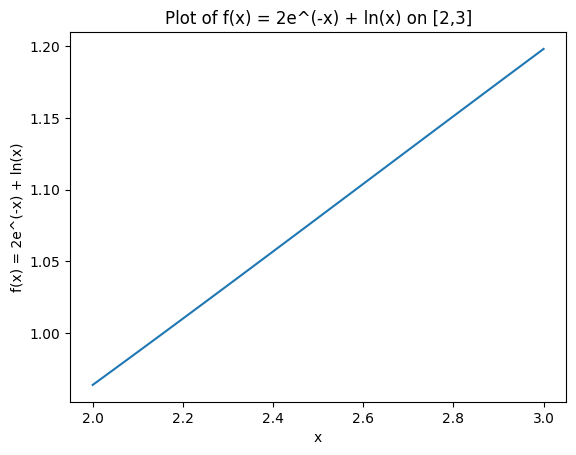

In [8]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(2,3,100)

f = 2*np.exp(-x) + np.log(x)

plt.plot(x, f)
plt.xlabel("x")
plt.ylabel("f(x) = 2e^(-x) + ln(x)")
plt.title("Plot of f(x) = 2e^(-x) + ln(x) on [2,3]")
plt.show()



**ΑΣΚΗΣΗ 3**

In [ ]:
import numpy as np

def f(x):
  s = x[0]**4 + x[0]**2 + x[1]**2
  return s

def grad_f(x):                     # Ορισμος των f, gradf
  s1 = 4*x[0]**3 + 2*x[0]
  s2 = 2*x[1]
  s = np.array([s1,s2])
  return s

x_k = np.array([1,1])
d_k = np.array([-3,-1])             # Δεδομενα ασκησης
eps = 1e-3

phi_0 = f(x_k)
dphi_0 = grad_f(x_k) * d_k
phi_1 = f(x_k + d_k)

c1 = phi_1 - phi_0 - dphi_0
c2 = dphi_0                    # mq(a) = c1*a^2 + c2*a +c3 : πολ/μο βαθμου 2
c3 = phi_0

a_min = - c2/(2*(c1))        # dmq/da = 0
r = phi_0 + eps*dphi_0

if phi_1.all() > r.all() : # Η εντολη .all() μπαινει διοτι θελω να συγκρινω ολα τα στοιχεια των δ/των μεταξυ τους (αλλιως πεταει error)
  print("Η 1η συνθηκη Armijo δεν ικανοποιειται")

print("φ_κ(0) =", phi_0)
print("φ_κ'(0) =", dphi_0)
print("φ_κ(1) =", phi_1)
print("c1 = ", c1)
print("â = ", a_min)


φ_κ(0) = 3
φ_κ'(0) = [-18  -2]
φ_κ(1) = 20
c1 =  [35 19]
â =  [0.25714286 0.05263158]
